# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** Sijie Yang, Zdravko Trivic, Yihan Zhu, Mahmoud Abdelrahman, Filip Biljecki*

---

**Note:** Each main section (marked with ## headers) in this notebook can be run independently. You can execute any section without needing to run the previous sections first. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

# UCI Part 2: Causal Forest Analytics

This notebook isolates the causal-forest analytics workflow for UCI interpretation, including feature-level and grouped importance analyses across activities.

This notebook loads a single modelling dataset that already contains both geospatial features and Social Activity Field targets (`*_field`).

Primary in-memory outputs:
- Feature-level importance summaries (activity-wise ATE rankings)
- Dimension-level signed effects and normalized shares
- Category-level signed effects and normalized shares
- `normalized_causal_importance` for downstream comparison with resident/expert weights

Data source used in this notebook:
- `data/data_uci_modelling.gpkg` (explanatory features and activity field targets: `*_field`)

This notebook does **not** save visualization files by default.
Run the final export cell to save normalized causal importance to:
- `data/data_uci_dimension_causal_importance.json`


## 1. Setup and Data Inputs

This section defines model inputs, feature-category mapping, data loading, standardization, and model factory configuration.


In [1]:
# =========================
# Section 1: Setup and Data Inputs
# =========================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML


In [2]:
# -------------------------
# 1.1 Inputs
# -------------------------
ACT_COLUMNS = ["eating", "nature", "community", "walking", "sightseeing"]

DIMENSION_FEATURES = {
    "SP": [
        "SP_1-E_comfort", "SP_2-E_sunshine_intensity", "SP_3-E_temp_inference",
        "SP_4-E_humidity_inference", "SP_5-E_wind_inference", "SP_6-E_greenery_rate",
        "SP_7-E_shading_area", "SP_8-E_heat_source", "SP_9-E_traffic_flow",
        "SP_1-D_imageability", "SP_2-D_enclosure", "SP_3-D_human_scale",
        "SP_4-D_complexity",
    ],
    "FC": [
        "FC_1-R_eating_rating", "FC_1-D_eating_density", "FC_2-R_retail_rating",
        "FC_2-D_retail_density", "FC_3-R_life_rating", "FC_3-D_life_density",
        "FC_4-R_recreation_rating", "FC_4-D_recreation_density", "FC_5-R_health_rating",
        "FC_5-D_health_density", "FC_6-R_community_rating", "FC_6-D_community_density",
        "FC_7-R_trans_rating", "FC_7-D_trans_density", "FC_1-H_HDB_density",
        "FC_1-G_review_polarity", "FC_2-G_review_subjectivity",
    ],
    "AC": [
        "AC_1-L_closeness400", "AC_2-L_closeness800", "AC_1-G_closeness2000",
        "AC_2-G_closeness6000", "AC_1-T_subway_accessibility",
        "AC_2-T_subway_density", "AC_3-T_bus_accessibility", "AC_4-T_bus_density",
    ],
    "CD": ["CD_1-P_population", "CD_1-B_building_density", "CD_1-L_leisure_density"],
}


In [3]:
# -------------------------
# 1.2 Category Mapping (feature_category)
# -------------------------
FEATURE_CATEGORY_RAW = {
    "SP_design_impression": ["SP_1-D_imageability", "SP_2-D_enclosure", "SP_3-D_human_scale", "SP_4-D_complexity"],
    "SP_environment_access": [
        "SP_1-E_comfort", "SP_7-E_shading_area", "SP_6-E_greenery_rate",
        "SP_4-E_humidity_inference", "SP_5-E_wind_inference", "SP_8-E_heat_source",
        "SP_3-E_temp_inference", "SP_2-E_sunshine_intensity", "SP_9-E_traffic_flow",
    ],
    "FC_poi_density": [
        "FC_1-D_eating_density", "FC_2-D_retail_density", "FC_3-D_life_density", "FC_4-D_recreation_density",
        "FC_5-D_health_density", "FC_6-D_community_density", "FC_7-D_trans_density",
    ],
    "FC_poi_quality": [
        "FC_1-R_eating_rating", "FC_2-R_retail_rating", "FC_3-R_life_rating", "FC_4-R_recreation_rating",
        "FC_5-R_health_rating", "FC_6-R_community_rating", "FC_7-R_trans_rating",
    ],
    "FC_hdb_density": ["FC_1-H_HDB_density"],
    "FC_user_review": ["FC_1-G_review_polarity", "FC_2-G_review_subjectivity"],
    "AC_local_closeness": ["AC_1-L_closeness400", "AC_2-L_closeness800"],
    "AC_global_closeness": ["AC_1-G_closeness2000", "AC_2-G_closeness6000"],
    "AC_public_transit": ["AC_1-T_subway_accessibility", "AC_2-T_subway_density", "AC_3-T_bus_accessibility", "AC_4-T_bus_density"],
    "CD_population_density": ["CD_1-P_population"],
    "CD_building_density": ["CD_1-B_building_density"],
    "CD_leisure_density": ["CD_1-L_leisure_density"],
}


In [4]:
# -------------------------
# 1.3 Load Data
# -------------------------
# Single source: data/data_uci_modelling.gpkg (features + activity field targets *_field)

if all(v in globals() for v in ["fx_df", "fx_available_features"]):
    # Prefer precomputed Social Activity Field block outputs
    df = fx_df.copy()

    # Ensure model targets use ACT_COLUMNS names (eating/nature/...)
    for act in ACT_COLUMNS:
        fcol = f"{act}_field"
        if fcol in df.columns:
            df[act] = df[fcol]

    existing_features = [c for c in fx_available_features if c in df.columns]
    existing_acts = [c for c in ACT_COLUMNS if c in df.columns]
    missing_acts = sorted(list(set(ACT_COLUMNS) - set(existing_acts)))

    print("Loaded from precomputed Social Activity Field block (fx_df)")
    print(f"Features found: {len(existing_features)}")
    print(f"Activities found: {len(existing_acts)}")
    if missing_acts:
        print("Missing activities (ignored):", missing_acts)
else:
    gpkg_path = "data/data_uci_modelling.gpkg"
    gdf = gpd.read_file(gpkg_path)
    df = gdf.copy()

    # Flatten all feature names in DIMENSION_FEATURES
    ALL_FEATURES = [f for dim in DIMENSION_FEATURES for f in DIMENSION_FEATURES[dim]]
    existing_features = [c for c in ALL_FEATURES if c in df.columns]
    missing_features = sorted(list(set(ALL_FEATURES) - set(existing_features)))

    # Activity field columns (*_field) are already in uci_modelling.gpkg
    act_field_map = {act: f"{act}_field" for act in ACT_COLUMNS}
    available_act_fields = {act: col for act, col in act_field_map.items() if col in df.columns}
    missing_acts = sorted(list(set(ACT_COLUMNS) - set(available_act_fields.keys())))

    if len(available_act_fields) == 0:
        raise RuntimeError("No activity field columns (*_field) found in data_uci_modelling.gpkg")

    # Map *_field to ACT_COLUMNS for model targets
    for act in ACT_COLUMNS:
        fcol = f"{act}_field"
        if fcol in df.columns:
            df[act] = df[fcol]

    existing_acts = [c for c in ACT_COLUMNS if c in df.columns]

    print(f"Loaded from: {gpkg_path}")
    print(f"Rows: {len(df)}")
    print(f"Features found: {len(existing_features)} / {len(ALL_FEATURES)}")
    if missing_features:
        print("Missing features (ignored):", missing_features)
    print(f"Activities found: {len(existing_acts)} / {len(ACT_COLUMNS)}")
    if missing_acts:
        print("Missing activities (ignored):", missing_acts)

    needed_cols = existing_features + existing_acts
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=needed_cols).copy()


# Enforce user-specified feature order for causal forest
FEATURE_ORDER_RAW = [
    'SP_imageability', 'SP_enclosure', 'SP_complexity', 'SP_artificial_heat_source', 'SP_traffic_flow',
    'SP_temperature_intensity', 'SP_sunshine_intensity', 'SP_comfort', 'SP_shading_area',
    'SP_human_scale', 'SP_greenery_rate', 'SP_humidity_inference', 'SP_wind_speed_inference',
    'FC_eating_density', 'FC_retail_density', 'FC_life_density', 'FC_recreation_density',
    'FC_health_density', 'FC_community_density', 'FC_trans_density', 'FC_HDB_density',
    'FC_eating_rating', 'FC_retail_rating', 'FC_life_rating', 'FC_recreation_rating',
    'FC_health_rating', 'FC_community_rating', 'FC_trans_rating',
    'FC_review_polarity', 'FC_review_subjectivity',
    'AC_closeness400', 'AC_closeness800', 'AC_closeness2000',
    'AC_closeness6000', 'AC_subway_accessibility', 'AC_subway_density',
    'AC_bus_accessibility', 'AC_bus_density', 'CD_population',
    'CD_building_density', 'CD_leisure_density'
]
FEATURE_ORDER_MAP = {
    'SP_imageability': 'SP_1-D_imageability',
    'SP_enclosure': 'SP_2-D_enclosure',
    'SP_complexity': 'SP_4-D_complexity',
    'SP_artificial_heat_source': 'SP_8-E_heat_source',
    'SP_traffic_flow': 'SP_9-E_traffic_flow',
    'SP_temperature_intensity': 'SP_3-E_temp_inference',
    'SP_sunshine_intensity': 'SP_2-E_sunshine_intensity',
    'SP_comfort': 'SP_1-E_comfort',
    'SP_shading_area': 'SP_7-E_shading_area',
    'SP_human_scale': 'SP_3-D_human_scale',
    'SP_greenery_rate': 'SP_6-E_greenery_rate',
    'SP_humidity_inference': 'SP_4-E_humidity_inference',
    'SP_wind_speed_inference': 'SP_5-E_wind_inference',
    'FC_eating_density': 'FC_1-D_eating_density',
    'FC_retail_density': 'FC_2-D_retail_density',
    'FC_life_density': 'FC_3-D_life_density',
    'FC_recreation_density': 'FC_4-D_recreation_density',
    'FC_health_density': 'FC_5-D_health_density',
    'FC_community_density': 'FC_6-D_community_density',
    'FC_trans_density': 'FC_7-D_trans_density',
    'FC_HDB_density': 'FC_1-H_HDB_density',
    'FC_eating_rating': 'FC_1-R_eating_rating',
    'FC_retail_rating': 'FC_2-R_retail_rating',
    'FC_life_rating': 'FC_3-R_life_rating',
    'FC_recreation_rating': 'FC_4-R_recreation_rating',
    'FC_health_rating': 'FC_5-R_health_rating',
    'FC_community_rating': 'FC_6-R_community_rating',
    'FC_trans_rating': 'FC_7-R_trans_rating',
    'FC_review_polarity': 'FC_1-G_review_polarity',
    'FC_review_subjectivity': 'FC_2-G_review_subjectivity',
    'AC_closeness400': 'AC_1-L_closeness400',
    'AC_closeness800': 'AC_2-L_closeness800',
    'AC_closeness2000': 'AC_1-G_closeness2000',
    'AC_closeness6000': 'AC_2-G_closeness6000',
    'AC_subway_accessibility': 'AC_1-T_subway_accessibility',
    'AC_subway_density': 'AC_2-T_subway_density',
    'AC_bus_accessibility': 'AC_3-T_bus_accessibility',
    'AC_bus_density': 'AC_4-T_bus_density',
    'CD_population': 'CD_1-P_population',
    'CD_building_density': 'CD_1-B_building_density',
    'CD_leisure_density': 'CD_1-L_leisure_density',
}
ordered_requested = [FEATURE_ORDER_MAP[f] for f in FEATURE_ORDER_RAW]
remaining = [f for f in existing_features if f not in ordered_requested]
existing_features = [f for f in ordered_requested if f in existing_features] + remaining
print(f"Causal feature order applied: {len(existing_features)} features")

print("Rows after dropna:", len(df))


Loaded from: data/data_uci_modelling.gpkg
Rows: 2096
Features found: 41 / 41
Activities found: 5 / 5
Causal feature order applied: 41 features
Rows after dropna: 2096


In [5]:
# -------------------------
# 1.4 Standardize X Once (Global)
# -------------------------
X = df[existing_features].values

if all(v in globals() for v in ["fx_x_scaled_df"]) and set(existing_features).issubset(set(fx_x_scaled_df.columns)):
    # Reuse scaled features from Social Activity Field when possible
    X_scaled = fx_x_scaled_df.loc[df.index, existing_features].values
    scaler = None
    print("Using scaled X from Social Activity Field block")
else:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

In [6]:
# -------------------------
# 1.5 Model Factory
# -------------------------
# Keep causal forest parameters exactly aligned with the reference setup

def make_cf(random_state=42):
    return CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=48, max_depth=5, random_state=random_state),
        model_t=RandomForestRegressor(n_estimators=48, max_depth=5, random_state=random_state),
        n_estimators=48,
        max_depth=5,
        subforest_size=4,
        random_state=random_state,
    )

## 2. Feature-Level Causal Importance

Estimate activity-specific feature importance (ATE-based) and generate ranking summaries and plots.


In [7]:
# -------------------------
# 2.1 Feature-Level Causal Importance (ATE) for Each Activity
#    with repeated seeds for stability (mean / std / 95% CI)
# -------------------------
CF_RANDOM_SEEDS = [42]
print("Causal Forest config: n_estimators=48, max_depth=5, subforest_size=4, seed=42")

feature_importance_mean = pd.DataFrame(index=existing_features, columns=existing_acts, dtype=float)
feature_importance_std = pd.DataFrame(index=existing_features, columns=existing_acts, dtype=float)
feature_importance_ci95_low = pd.DataFrame(index=existing_features, columns=existing_acts, dtype=float)
feature_importance_ci95_high = pd.DataFrame(index=existing_features, columns=existing_acts, dtype=float)

total_tasks = len(existing_acts) * len(existing_features) * len(CF_RANDOM_SEEDS)
progress = tqdm(total=total_tasks, desc="Causal tasks", leave=True)

for act in existing_acts:
    # Prefer extracted target from social activity field; fallback to *_extracted column; then raw target
    if "fx_target_series" in globals() and act in fx_target_series:
        y = np.asarray(fx_target_series[act]).reshape(-1)
    elif f"{act}_extracted" in df.columns:
        y = df[f"{act}_extracted"].values.reshape(-1)
    else:
        y = df[act].values.reshape(-1)

    for i, feat in enumerate(existing_features):
        T = X_scaled[:, i].reshape(-1, 1)
        W = np.delete(X_scaled, i, axis=1)

        ate_runs = []
        for seed in CF_RANDOM_SEEDS:
            cf = make_cf(random_state=seed)
            try:
                cf.fit(y, T, X=X_scaled, W=W)
                ate = float(np.mean(cf.effect(X_scaled)))
                ate_runs.append(ate)

                # Model-based 95% CI for ATE (single-seed compatible)
                ci_low_arr, ci_high_arr = cf.ate_interval(X=X_scaled, alpha=0.05)
                ci_low_model = float(np.asarray(ci_low_arr).ravel()[0])
                ci_high_model = float(np.asarray(ci_high_arr).ravel()[0])
            except Exception as e:
                print(f"[WARN] {act} / {feat} / seed={seed} failed: {e}")
            finally:
                progress.update(1)
                progress.set_postfix_str(f"act={act}, feat={feat}, seed={seed}")

        if len(ate_runs) == 0:
            feature_importance_mean.loc[feat, act] = 0.0
            feature_importance_std.loc[feat, act] = 0.0
            feature_importance_ci95_low.loc[feat, act] = 0.0
            feature_importance_ci95_high.loc[feat, act] = 0.0
            continue

        arr = np.asarray(ate_runs, dtype=float)
        mean_v = float(np.mean(arr))
        std_v = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
        se_v = std_v / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
        ci_delta = 1.96 * se_v

        feature_importance_mean.loc[feat, act] = mean_v
        feature_importance_std.loc[feat, act] = std_v

        # Prefer model-based CI when single seed; otherwise keep across-seed CI
        if len(CF_RANDOM_SEEDS) == 1:
            feature_importance_ci95_low.loc[feat, act] = ci_low_model
            feature_importance_ci95_high.loc[feat, act] = ci_high_model
        else:
            feature_importance_ci95_low.loc[feat, act] = mean_v - ci_delta
            feature_importance_ci95_high.loc[feat, act] = mean_v + ci_delta

progress.close()

# Keep compatibility with downstream code that expects `feature_importance`
feature_importance = feature_importance_mean.copy()

display(feature_importance)

Causal Forest config: n_estimators=48, max_depth=5, subforest_size=4, seed=42


Causal tasks: 100%|██████████| 205/205 [05:30<00:00,  1.61s/it, act=sightseeing, feat=CD_1-L_leisure_density, seed=42]     


,eating,nature,community,walking,sightseeing
SP_1-D_imageability,-3.204557,3.846211,0.316763,8.134996,0.677302
SP_2-D_enclosure,2.630703,-6.352350,1.699892,-2.095533,-5.447491
SP_4-D_complexity,-1.760597,0.287144,-3.277659,1.021761,-3.557803
SP_8-E_heat_source,1.890030,-1.021428,-0.000328,1.726050,0.452578
SP_9-E_traffic_flow,1.496647,1.326060,0.000438,-2.932883,-5.088226
SP_3-E_temp_inference,0.082174,8.775344,1.455254,0.473688,5.065942
SP_2-E_sunshine_intensity,-1.673285,0.826711,0.176726,2.930666,2.238652
SP_1-E_comfort,-3.679163,4.336196,1.159456,6.779800,-1.470398
SP_7-E_shading_area,-1.895311,-1.433121,1.175206,-1.627095,-5.304091
SP_3-D_human_scale,-1.154676,1.353838,1.853045,2.680057,1.353865


In [8]:
# 2.2 Tidy Summary Table for Feature Importance Reporting
feature_importance_stats = []
for act in existing_acts:
    for feat in existing_features:
        mean_v = float(feature_importance_mean.loc[feat, act])
        std_v = float(feature_importance_std.loc[feat, act])
        ci_low = float(feature_importance_ci95_low.loc[feat, act])
        ci_high = float(feature_importance_ci95_high.loc[feat, act])

        feature_importance_stats.append({
            "activity": act,
            "feature": feat,
            "ate_mean": mean_v,
            "ate_std": std_v,
            "ci95_low": ci_low,
            "ci95_high": ci_high,
        })

feature_importance_stats_df = pd.DataFrame(feature_importance_stats)
display(feature_importance_stats_df.head(30))

,activity,feature,ate_mean,ate_std,ci95_low,ci95_high
0,eating,SP_1-D_imageability,-3.204557,0.0,-33.488974,27.079860
1,eating,SP_2-D_enclosure,2.630703,0.0,-21.030729,26.292134
2,eating,SP_4-D_complexity,-1.760597,0.0,-29.875450,26.354257
3,eating,SP_8-E_heat_source,1.890030,0.0,-26.202111,29.982171
4,eating,SP_9-E_traffic_flow,1.496647,0.0,-22.286652,25.279947
5,eating,SP_3-E_temp_inference,0.082174,0.0,-31.625336,31.789683
6,eating,SP_2-E_sunshine_intensity,-1.673285,0.0,-23.415159,20.068589
7,eating,SP_1-E_comfort,-3.679163,0.0,-38.567022,31.208697
8,eating,SP_7-E_shading_area,-1.895311,0.0,-31.159783,27.369161
9,eating,SP_3-D_human_scale,-1.154676,0.0,-26.134686,23.825334


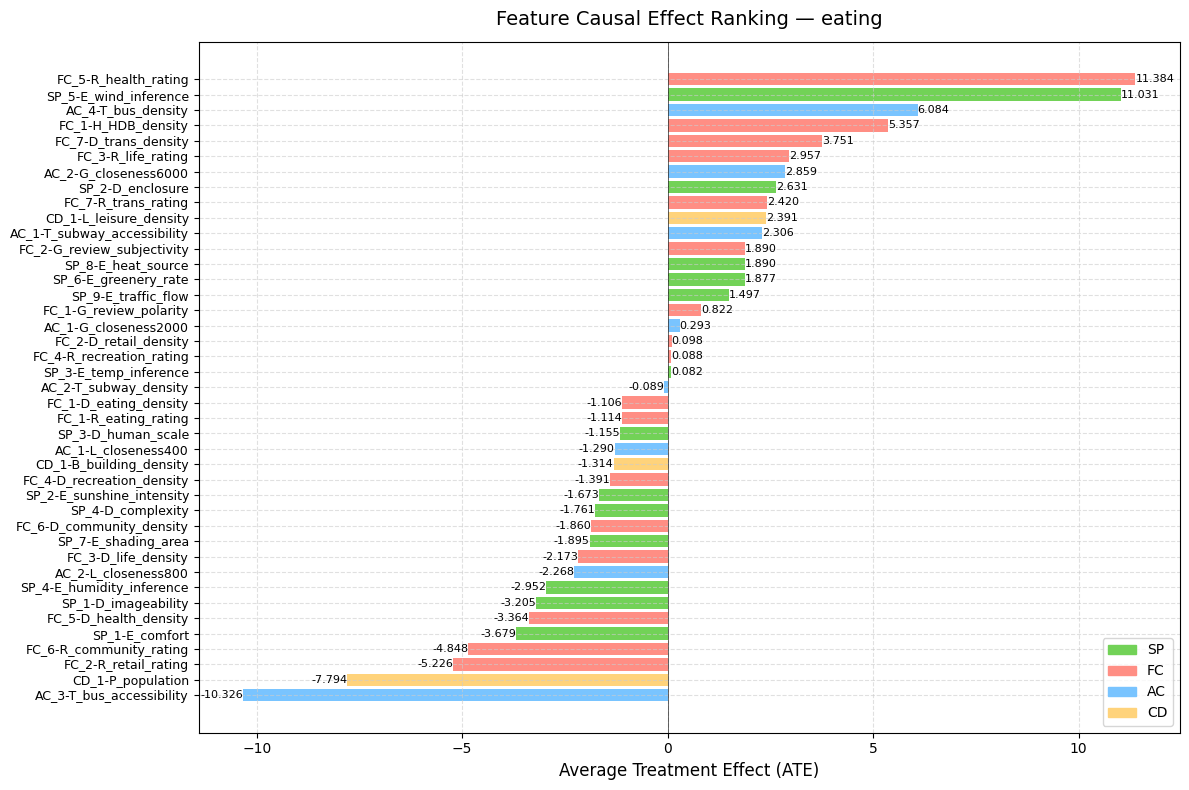

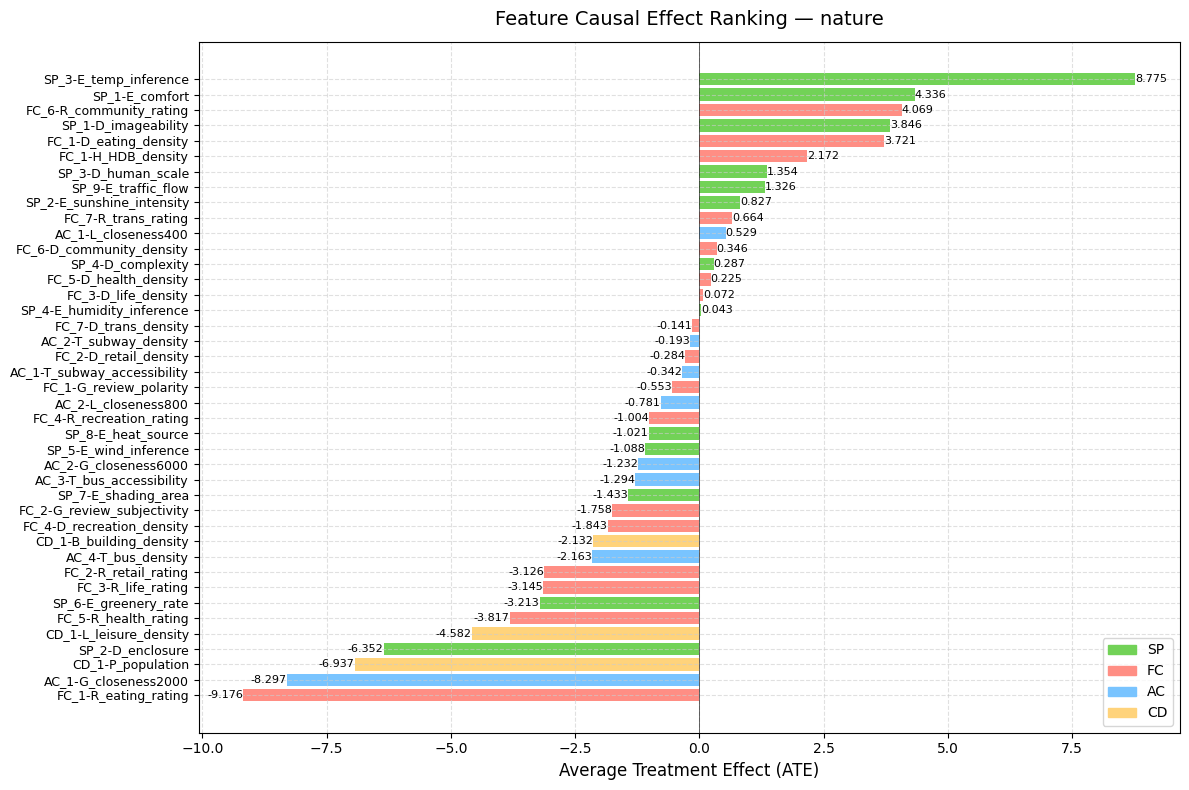

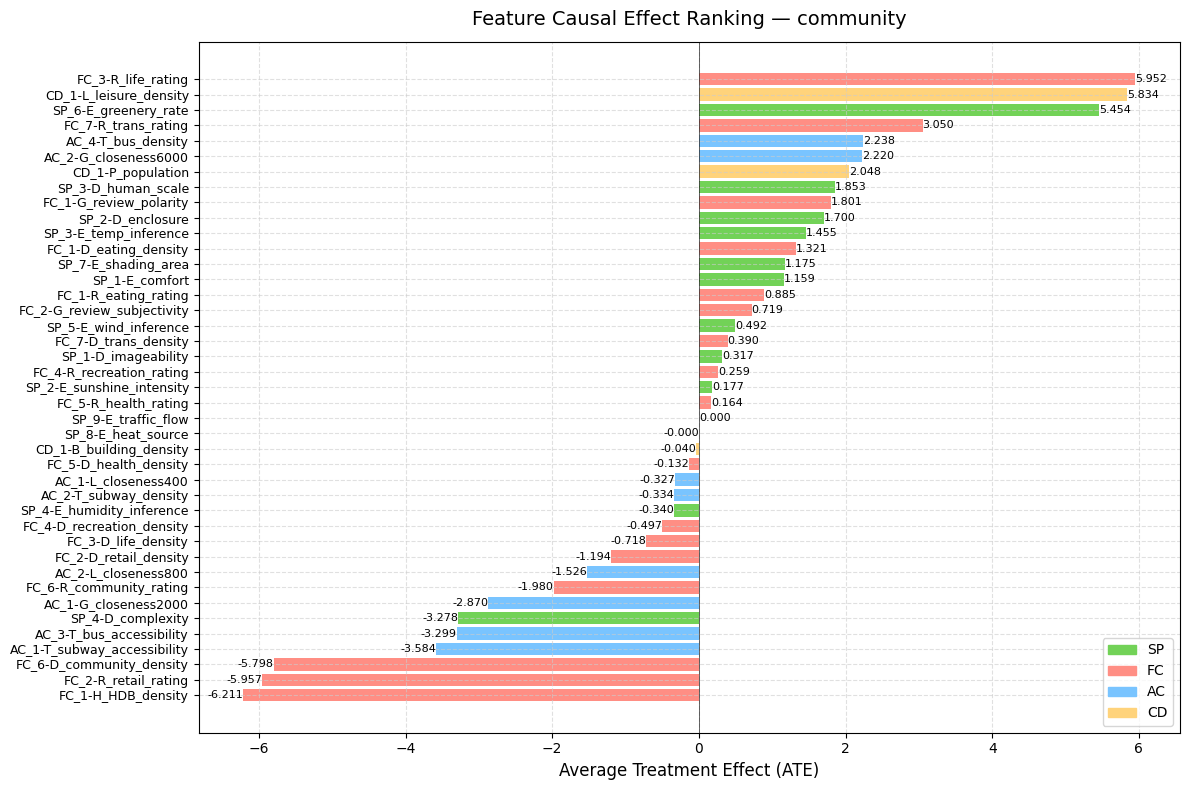

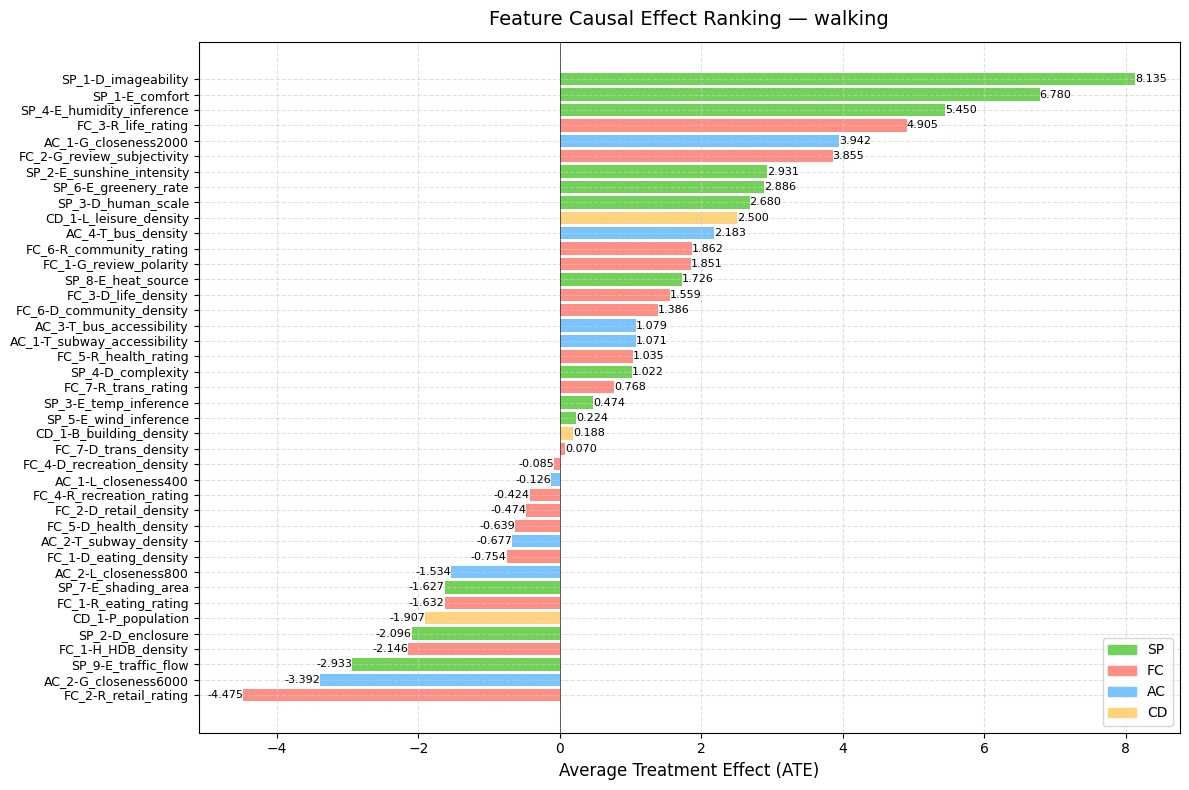

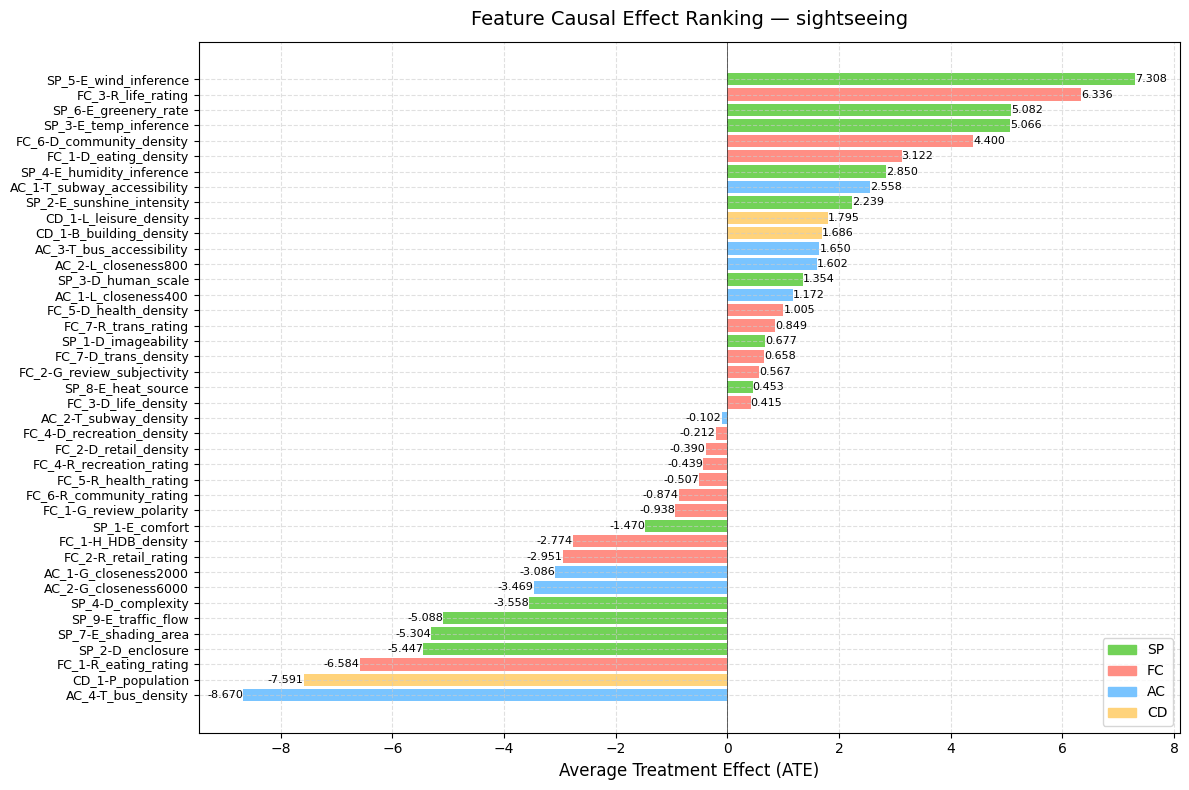

In [9]:
# -------------------------
# 2.3 Plot Helper: Per-Activity Feature Ranking (barh)
# -------------------------
dimension_colors = {
    "SP": "#72D257",  # green
    "FC": "#FF8E84",  # coral
    "AC": "#79C4FF",  # blue
    "CD": "#FFD37B",  # yellow
}

def feature_to_dim(feat: str) -> str:
    # Feature names begin with "SP_", "FC_", "AC_", "CD_"
    return feat.split("_", 1)[0] if "_" in feat else "OTHER"

def plot_feature_ranking(act, top_k=None):
    s = feature_importance[act].sort_values(ascending=True)
    if top_k is not None:
        s = s.tail(top_k)

    colors = [dimension_colors.get(feature_to_dim(f), "#888888") for f in s.index]

    fig = plt.figure(figsize=(12, 8), facecolor="white")
    ax = fig.add_subplot(111)
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#CCCCCC")
    bars = ax.barh(range(len(s)), s.values, color=colors)

    ax.set_title(f"Feature Causal Effect Ranking — {act}", fontsize=14, pad=12)
    ax.set_xlabel("Average Treatment Effect (ATE)", fontsize=12)
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels(s.index, fontsize=9)

    ax.axvline(0, color="black", linewidth=0.7, alpha=0.6)

    for j, b in enumerate(bars):
        w = b.get_width()
        ax.text(
            w, j, f"{w:.3f}",
            ha="left" if w >= 0 else "right",
            va="center",
            fontsize=8
        )

    legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=k) for k, c in dimension_colors.items()]
    ax.legend(handles=legend_handles, loc="lower right")

    plt.tight_layout()
    plt.show()

# Plot all activities
for act in existing_acts:
    plot_feature_ranking(act)


## 3. Dimension-Level Signed Effects

Aggregate effects to dimension level (SP/FC/AC/CD), split into positive and negative contributions, and compute normalized shares.


In [10]:
# -------------------------
# 3.1 Dimension-Level Positive/Negative Weights per Activity
#    (same spirit as your earlier cluster aggregation)
# -------------------------
dimension_importance = {act: {} for act in existing_acts}

for act in existing_acts:
    for dim, feats in DIMENSION_FEATURES.items():
        valid = [f for f in feats if f in feature_importance.index]
        if not valid:
            continue

        vals = feature_importance.loc[valid, act].astype(float)
        pos = vals[vals > 0]
        neg = vals[vals < 0]

        # Use "average magnitude" style like you did (sum / count)
        pos_w = pos.sum() / len(pos) if len(pos) else 0.0
        neg_w = neg.abs().sum() / len(neg) if len(neg) else 0.0

        dimension_importance[act][dim] = {"positive": float(pos_w), "negative": float(neg_w)}

# Display dimension importance table
dim_rows = []
for act in existing_acts:
    for dim in dimension_importance[act]:
        dim_rows.append([act, dim,
                         dimension_importance[act][dim]["positive"],
                         dimension_importance[act][dim]["negative"],
                         dimension_importance[act][dim]["positive"] + dimension_importance[act][dim]["negative"]])
dim_df = pd.DataFrame(dim_rows, columns=["activity", "dimension", "positive", "negative", "total"])
display(dim_df.sort_values(["activity", "total"], ascending=[True, False]))


,activity,dimension,positive,negative,total
9,community,FC,1.615644,2.810996,4.426639
10,community,AC,2.229227,1.990104,4.219330
11,community,CD,3.940969,0.039650,3.980619
8,community,SP,1.378261,1.205856,2.584117
3,eating,CD,2.391422,4.554329,6.945752
2,eating,AC,2.885300,3.493237,6.378536
1,eating,FC,3.196453,2.635203,5.831656
0,eating,SP,3.167869,2.331401,5.499270
4,nature,SP,2.599319,2.621659,5.220978
7,nature,CD,0.000000,4.550196,4.550196


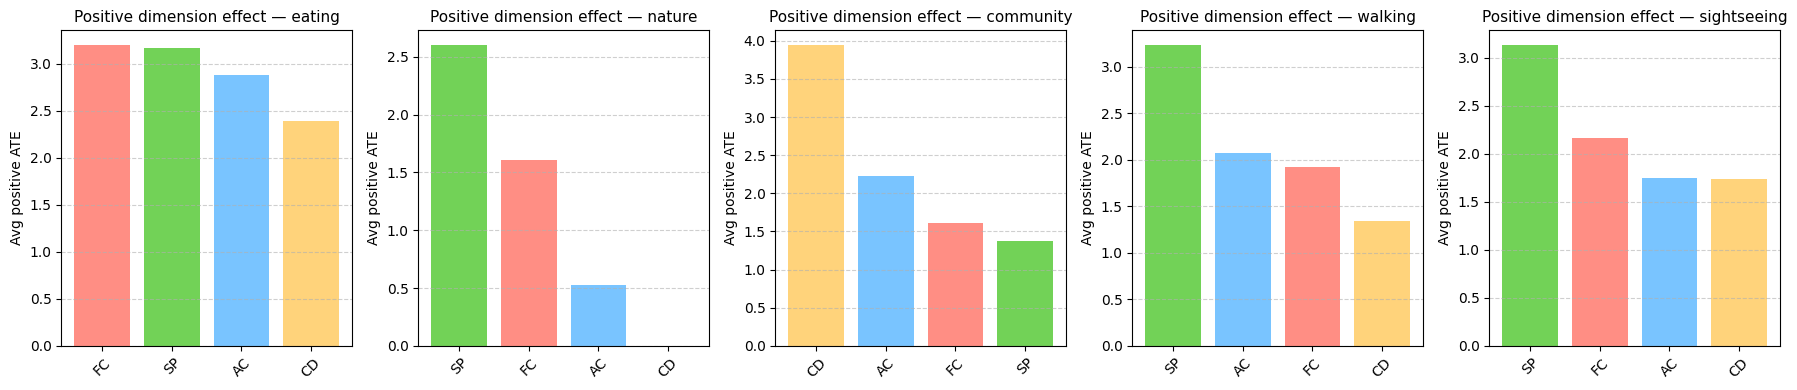

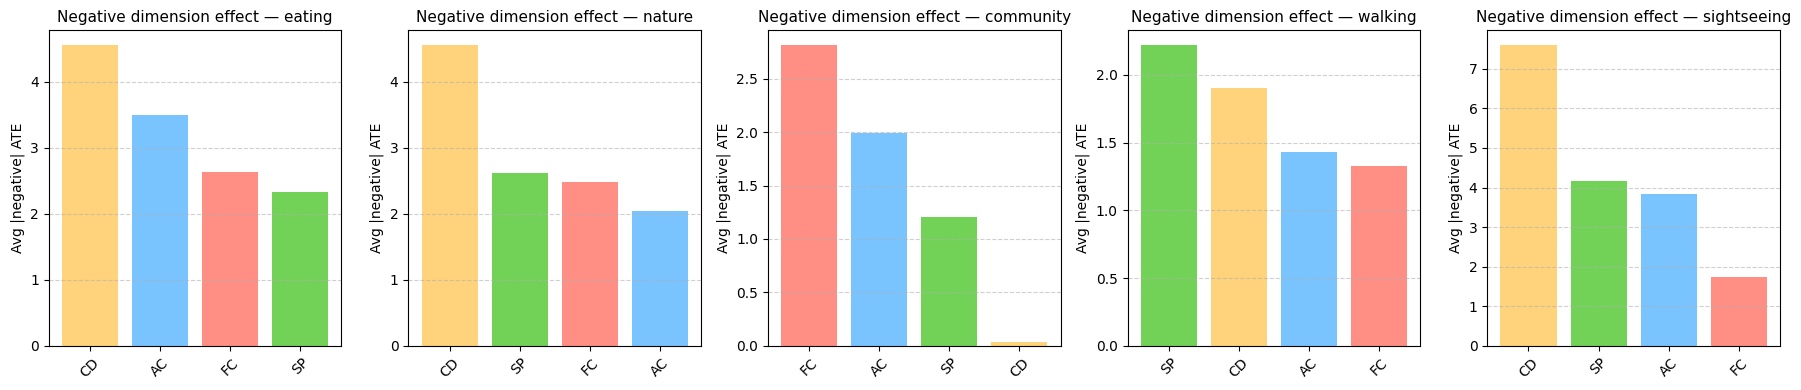

In [11]:
# -------------------------
# 3.2 Plot Helper: Dimension Positive/Negative Bars
# -------------------------
def plot_dimension_weights():
    # Positive
    fig = plt.figure(figsize=(18, 4), facecolor="white")
    for i, act in enumerate(existing_acts):
        ax = fig.add_subplot(1, len(existing_acts), i + 1)
        data = [(d,
                 dimension_importance[act].get(d, {}).get("positive", 0.0),
                 dimension_importance[act].get(d, {}).get("negative", 0.0))
                for d in DIMENSION_FEATURES.keys()]
        dfp = pd.DataFrame(data, columns=["dim", "pos", "neg"]).sort_values("pos", ascending=False)

        ax.bar(dfp["dim"], dfp["pos"], color=[dimension_colors.get(d, "#888888") for d in dfp["dim"]])
        ax.set_title(f"Positive dimension effect — {act}", fontsize=11)
        ax.set_ylabel("Avg positive ATE", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    # Negative
    fig = plt.figure(figsize=(18, 4), facecolor="white")
    for i, act in enumerate(existing_acts):
        ax = fig.add_subplot(1, len(existing_acts), i + 1)
        data = [(d,
                 dimension_importance[act].get(d, {}).get("positive", 0.0),
                 dimension_importance[act].get(d, {}).get("negative", 0.0))
                for d in DIMENSION_FEATURES.keys()]
        dfn = pd.DataFrame(data, columns=["dim", "pos", "neg"]).sort_values("neg", ascending=False)

        ax.bar(dfn["dim"], dfn["neg"], color=[dimension_colors.get(d, "#888888") for d in dfn["dim"]])
        ax.set_title(f"Negative dimension effect — {act}", fontsize=11)
        ax.set_ylabel("Avg |negative| ATE", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

plot_dimension_weights()


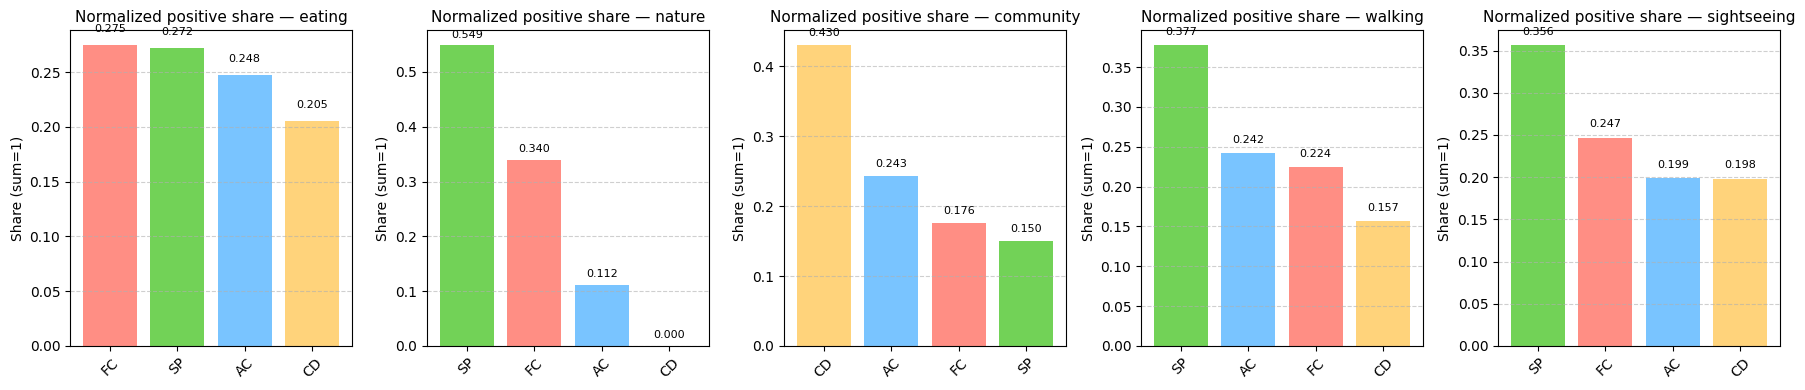

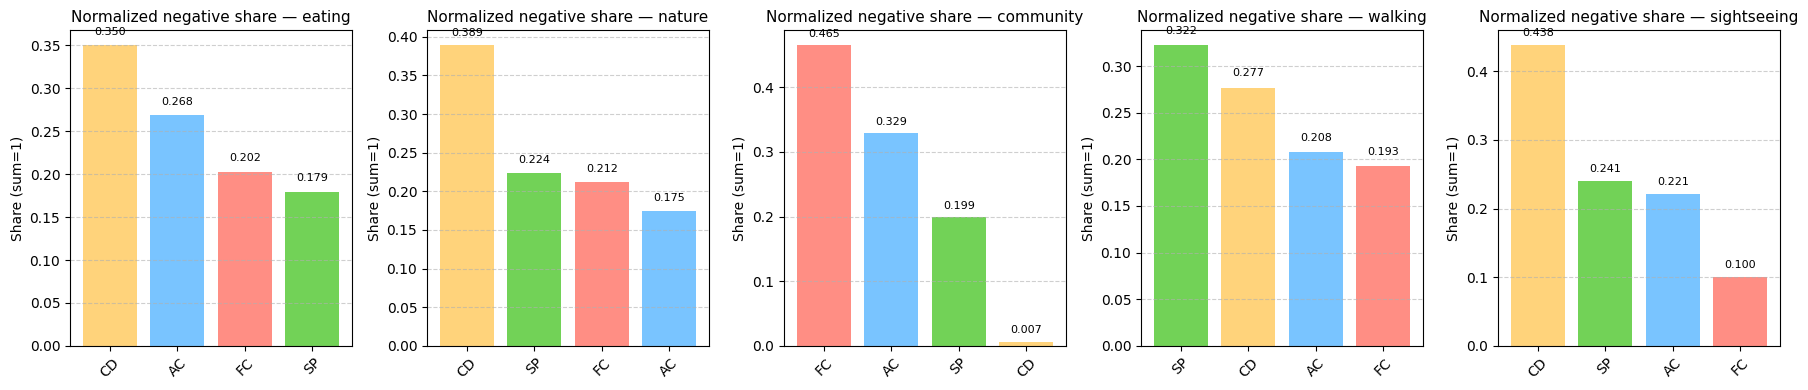

In [12]:
# -------------------------
# 3.3 Normalized Dimension Weights (Shares Sum to 1)
# -------------------------
normalized_dimension_importance = {act: {} for act in existing_acts}

for act in existing_acts:
    total_pos = sum(dimension_importance[act].get(dim, {}).get("positive", 0.0) for dim in DIMENSION_FEATURES.keys())
    total_neg = sum(dimension_importance[act].get(dim, {}).get("negative", 0.0) for dim in DIMENSION_FEATURES.keys())

    for dim in DIMENSION_FEATURES.keys():
        pos = dimension_importance[act].get(dim, {}).get("positive", 0.0)
        neg = dimension_importance[act].get(dim, {}).get("negative", 0.0)
        normalized_dimension_importance[act][dim] = {
            "positive": (pos / total_pos) if total_pos > 0 else 0.0,
            "negative": (neg / total_neg) if total_neg > 0 else 0.0
        }


def plot_normalized_dimension():
    # Normalized positive
    fig = plt.figure(figsize=(18, 4), facecolor="white")
    for i, act in enumerate(existing_acts):
        ax = fig.add_subplot(1, len(existing_acts), i + 1)
        data = [(dim, normalized_dimension_importance[act][dim]["positive"]) for dim in DIMENSION_FEATURES.keys()]
        dff = pd.DataFrame(data, columns=["dim", "share"]).sort_values("share", ascending=False)

        bars = ax.bar(dff["dim"], dff["share"], color=[dimension_colors.get(d, "#888888") for d in dff["dim"]])
        ax.set_title(f"Normalized positive share — {act}", fontsize=11)
        ax.set_ylabel("Share (sum=1)", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis="x", rotation=45)
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{b.get_height():.3f}",
                    ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Normalized negative
    fig = plt.figure(figsize=(18, 4), facecolor="white")
    for i, act in enumerate(existing_acts):
        ax = fig.add_subplot(1, len(existing_acts), i + 1)
        data = [(dim, normalized_dimension_importance[act][dim]["negative"]) for dim in DIMENSION_FEATURES.keys()]
        dff = pd.DataFrame(data, columns=["dim", "share"]).sort_values("share", ascending=False)

        bars = ax.bar(dff["dim"], dff["share"], color=[dimension_colors.get(d, "#888888") for d in dff["dim"]])
        ax.set_title(f"Normalized negative share — {act}", fontsize=11)
        ax.set_ylabel("Share (sum=1)", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis="x", rotation=45)
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{b.get_height():.3f}",
                    ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

plot_normalized_dimension()

## 4. Category-Level Signed Effects

Aggregate effects to category level, report positive/negative balances, and compare cross-activity patterns.


In [13]:
# -------------------------
# 4.1 Category-Level Positive/Negative Weights per Activity
# -------------------------
CATEGORY_FEATURES = {}
missing_category_features = {}
for cat, feats in FEATURE_CATEGORY_RAW.items():
    valid = [f for f in feats if f in feature_importance.index]
    missing = [f for f in feats if f not in feature_importance.index]
    CATEGORY_FEATURES[cat] = valid
    if missing:
        missing_category_features[cat] = missing

if missing_category_features:
    print("[INFO] Missing category features (ignored):", missing_category_features)

category_importance = {act: {} for act in existing_acts}
for act in existing_acts:
    for cat, feats in CATEGORY_FEATURES.items():
        if not feats:
            continue
        vals = feature_importance.loc[feats, act].astype(float)
        pos = vals[vals > 0]
        neg = vals[vals < 0]
        pos_w = pos.sum() / len(pos) if len(pos) else 0.0
        neg_w = neg.abs().sum() / len(neg) if len(neg) else 0.0
        category_importance[act][cat] = {"positive": float(pos_w), "negative": float(neg_w)}

cat_rows = []
for act in existing_acts:
    for cat in category_importance[act]:
        cat_rows.append([
            act, cat,
            category_importance[act][cat]["positive"],
            category_importance[act][cat]["negative"],
            category_importance[act][cat]["positive"] + category_importance[act][cat]["negative"],
        ])
cat_df = pd.DataFrame(cat_rows, columns=["activity", "category", "positive", "negative", "total"])
display(cat_df.sort_values(["activity", "total"], ascending=[True, False]))


,activity,category,positive,negative,total
28,community,FC_hdb_density,0.000000,6.211435,6.211435
27,community,FC_poi_quality,2.061956,3.968725,6.030681
35,community,CD_leisure_density,5.834242,0.000000,5.834242
31,community,AC_global_closeness,2.220191,2.870204,5.090395
32,community,AC_public_transit,2.238262,2.405626,4.643888
24,community,SP_design_impression,1.289900,3.277659,4.567559
26,community,FC_poi_density,0.855524,1.667816,2.523340
33,community,CD_population_density,2.047697,0.000000,2.047697
25,community,SP_environment_access,1.416130,0.169954,1.586084
29,community,FC_user_review,1.259983,0.000000,1.259983


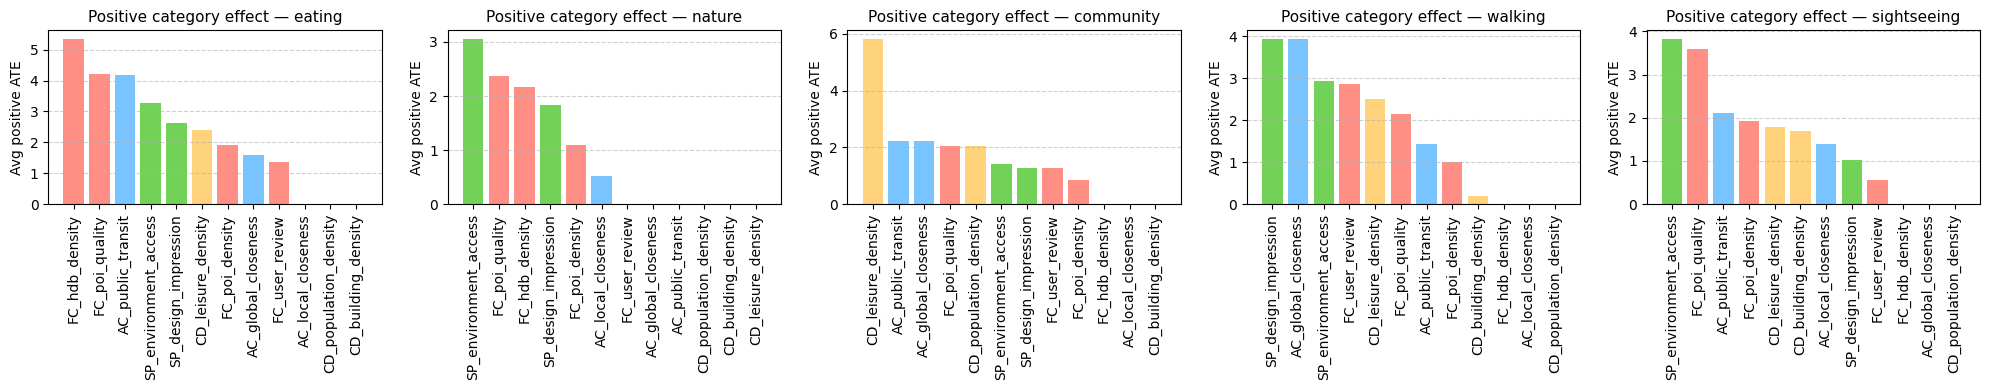

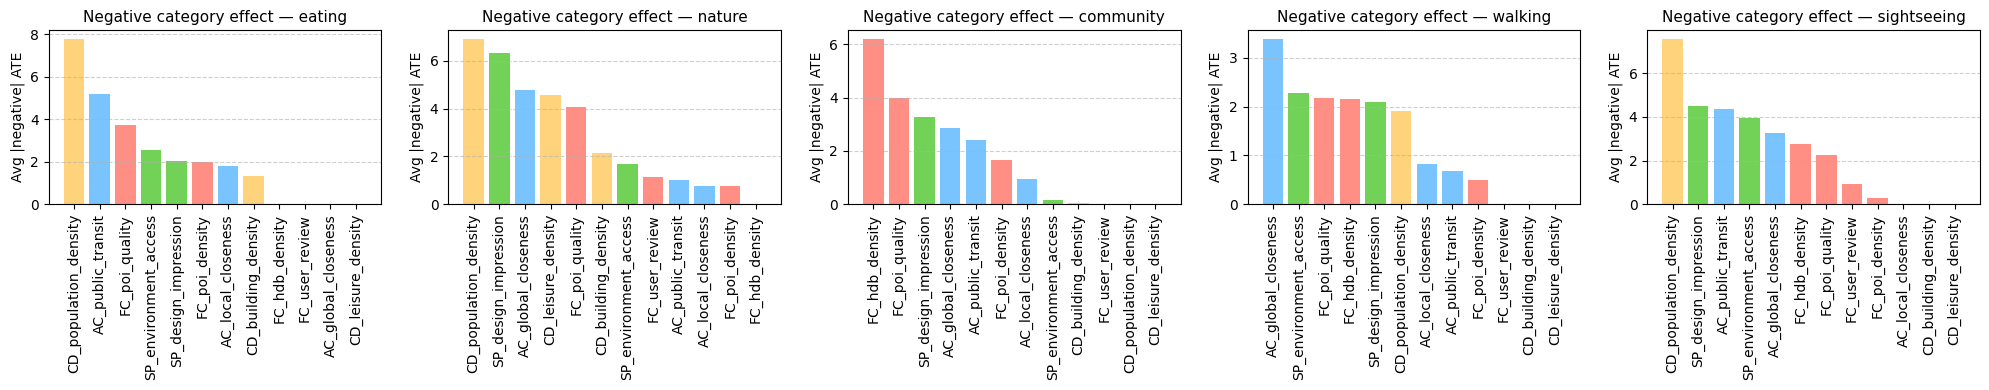

In [14]:
# -------------------------
# 4.2 Plot Helper: Category Positive/Negative Bars
# -------------------------
def plot_category_weights():
    # Positive
    fig = plt.figure(figsize=(20, 4), facecolor="white")
    for i, act in enumerate(existing_acts):
        ax = fig.add_subplot(1, len(existing_acts), i + 1)
        data = [(c,
                 category_importance[act].get(c, {}).get("positive", 0.0),
                 category_importance[act].get(c, {}).get("negative", 0.0))
                for c in FEATURE_CATEGORY_RAW.keys()]
        dfp = pd.DataFrame(data, columns=["cat", "pos", "neg"]).sort_values("pos", ascending=False)

        colors = [dimension_colors.get(c.split("_")[0], "#888888") for c in dfp["cat"]]
        ax.bar(dfp["cat"], dfp["pos"], color=colors)
        ax.set_title(f"Positive category effect — {act}", fontsize=11)
        ax.set_ylabel("Avg positive ATE", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()

    # Negative
    fig = plt.figure(figsize=(20, 4), facecolor="white")
    for i, act in enumerate(existing_acts):
        ax = fig.add_subplot(1, len(existing_acts), i + 1)
        data = [(c,
                 category_importance[act].get(c, {}).get("positive", 0.0),
                 category_importance[act].get(c, {}).get("negative", 0.0))
                for c in FEATURE_CATEGORY_RAW.keys()]
        dfn = pd.DataFrame(data, columns=["cat", "pos", "neg"]).sort_values("neg", ascending=False)

        colors = [dimension_colors.get(c.split("_")[0], "#888888") for c in dfn["cat"]]
        ax.bar(dfn["cat"], dfn["neg"], color=colors)
        ax.set_title(f"Negative category effect — {act}", fontsize=11)
        ax.set_ylabel("Avg |negative| ATE", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()

plot_category_weights()


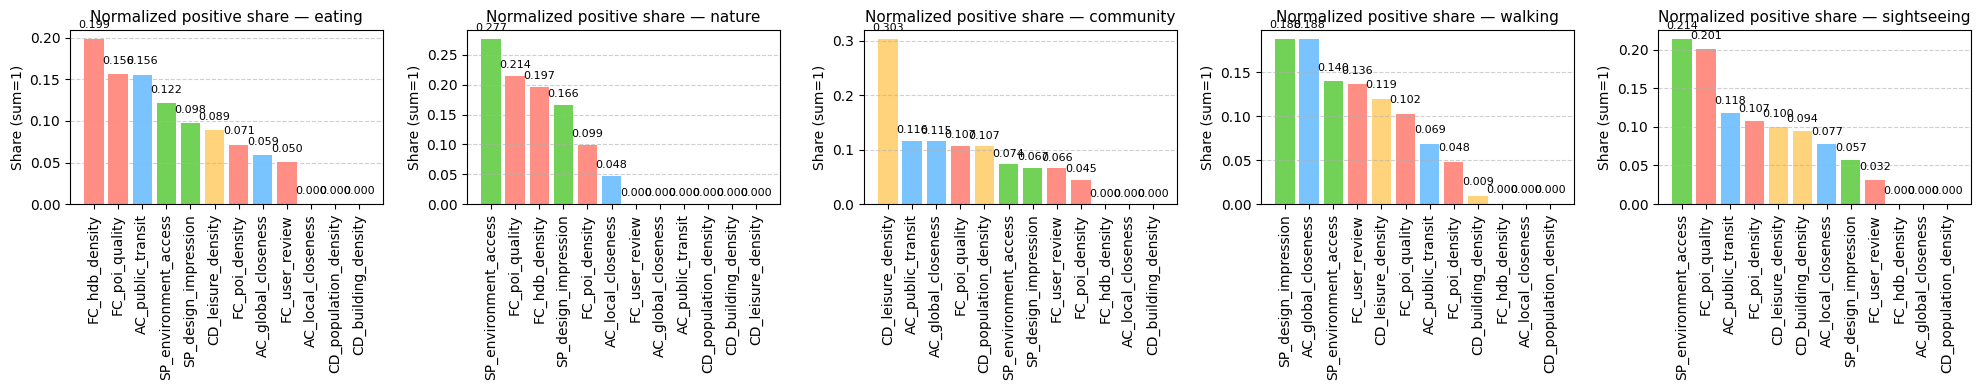

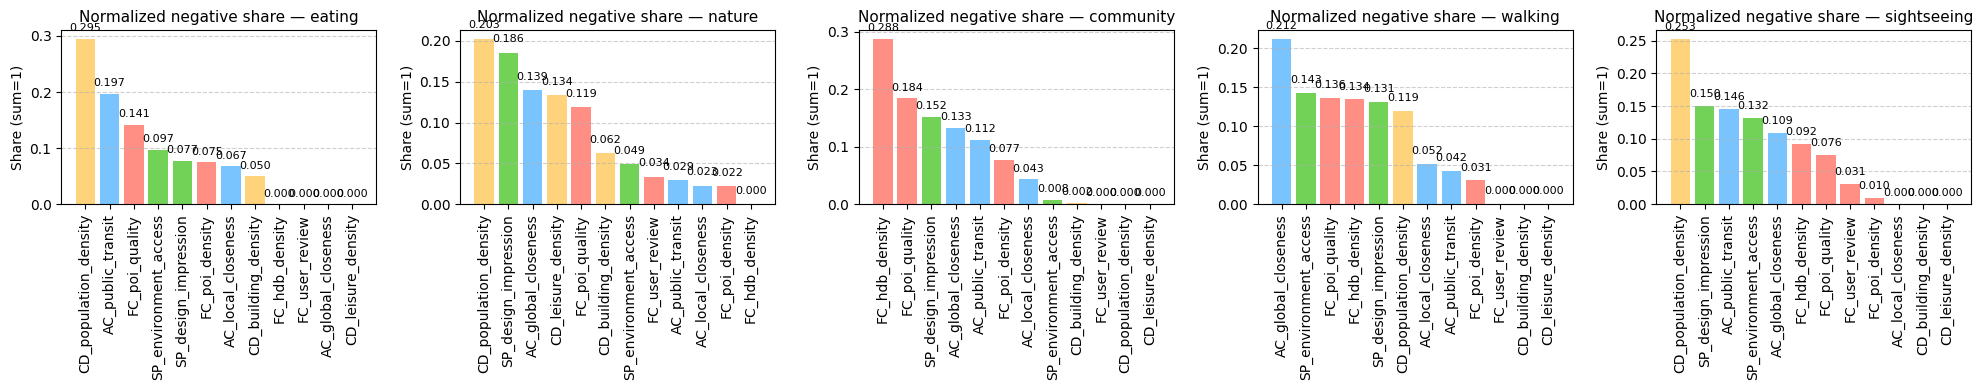

Done. Figures displayed (not saved to disk).


In [15]:
# -------------------------
# 4.3 Normalized Category Weights (Shares Sum to 1)
# -------------------------
normalized_category_importance = {act: {} for act in existing_acts}
for act in existing_acts:
    total_pos = sum(category_importance[act].get(cat, {}).get("positive", 0.0) for cat in FEATURE_CATEGORY_RAW.keys())
    total_neg = sum(category_importance[act].get(cat, {}).get("negative", 0.0) for cat in FEATURE_CATEGORY_RAW.keys())

    for cat in FEATURE_CATEGORY_RAW.keys():
        pos = category_importance[act].get(cat, {}).get("positive", 0.0)
        neg = category_importance[act].get(cat, {}).get("negative", 0.0)
        normalized_category_importance[act][cat] = {
            "positive": (pos / total_pos) if total_pos > 0 else 0.0,
            "negative": (neg / total_neg) if total_neg > 0 else 0.0,
        }

def plot_normalized_category():
    # Normalized positive
    fig = plt.figure(figsize=(20, 4), facecolor="white")
    for i, act in enumerate(existing_acts):
        ax = fig.add_subplot(1, len(existing_acts), i + 1)
        data = [(cat, normalized_category_importance[act][cat]["positive"]) for cat in FEATURE_CATEGORY_RAW.keys()]
        dff = pd.DataFrame(data, columns=["cat", "share"]).sort_values("share", ascending=False)

        colors = [dimension_colors.get(c.split("_")[0], "#888888") for c in dff["cat"]]
        bars = ax.bar(dff["cat"], dff["share"], color=colors)
        ax.set_title(f"Normalized positive share — {act}", fontsize=11)
        ax.set_ylabel("Share (sum=1)", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis="x", rotation=90)
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{b.get_height():.3f}",
                    ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Normalized negative
    fig = plt.figure(figsize=(20, 4), facecolor="white")
    for i, act in enumerate(existing_acts):
        ax = fig.add_subplot(1, len(existing_acts), i + 1)
        data = [(cat, normalized_category_importance[act][cat]["negative"]) for cat in FEATURE_CATEGORY_RAW.keys()]
        dff = pd.DataFrame(data, columns=["cat", "share"]).sort_values("share", ascending=False)

        colors = [dimension_colors.get(c.split("_")[0], "#888888") for c in dff["cat"]]
        bars = ax.bar(dff["cat"], dff["share"], color=colors)
        ax.set_title(f"Normalized negative share — {act}", fontsize=11)
        ax.set_ylabel("Share (sum=1)", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis="x", rotation=90)
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{b.get_height():.3f}",
                    ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

plot_normalized_category()

print("Done. Figures displayed (not saved to disk).")

## 5. Composition and Absolute-Effect Summaries

Summarize positive/negative feature proportions and absolute-effect importance by category and dimension.



Category Analysis for eating:
----------------------------------------------------------------------
Category Name                Positive Ratio  Negative Ratio  Total Features 
----------------------------------------------------------------------
FC_hdb_density               1.00      0.00      1              
FC_user_review               1.00      0.00      2              
AC_global_closeness          1.00      0.00      2              
CD_leisure_density           1.00      0.00      1              
FC_poi_quality               0.57      0.43      7              
SP_environment_access        0.56      0.44      9              
AC_public_transit            0.50      0.50      4              
FC_poi_density               0.29      0.71      7              
SP_design_impression         0.25      0.75      4              
AC_local_closeness           0.00      1.00      2              
CD_population_density        0.00      1.00      1              
CD_building_density          0.00  

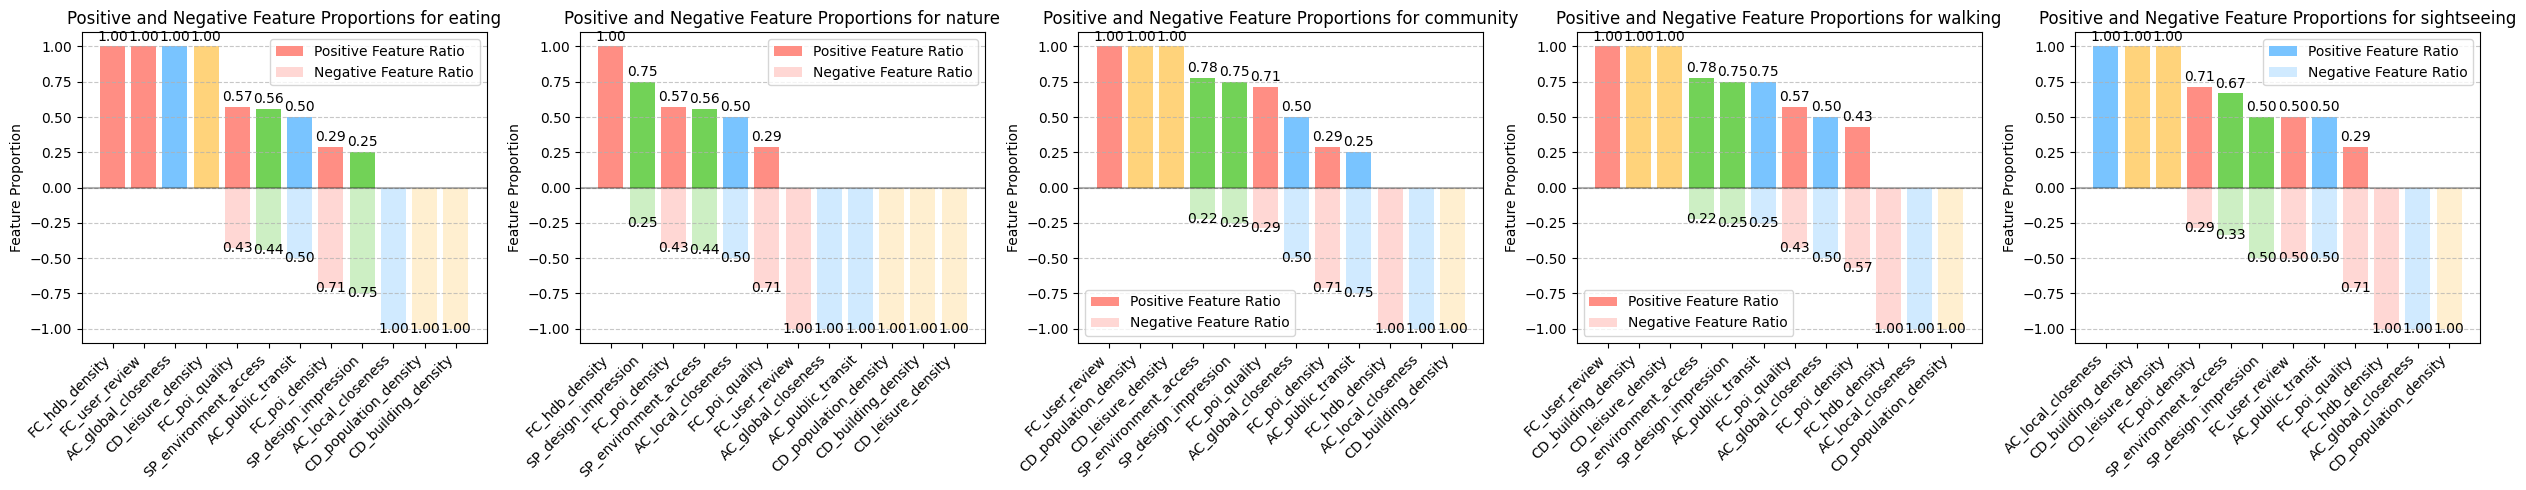

In [16]:
# -------------------------
# 5.1 Positive/Negative Feature Proportion by Category and Activity
# -------------------------
# Activity columns in this notebook are activity names (e.g., eating/nature/...) from extracted-target causal analysis
activity_columns = [a for a in existing_acts if a in feature_importance.columns]
category_feature_counts = {}

# Iterate through each activity
for act in activity_columns:
    category_feature_counts[act] = {}

    # Iterate through each feature category (same definition used in 2c)
    for category_name, features in FEATURE_CATEGORY_RAW.items():
        # Only calculate features that exist in feature_importance
        valid_features = [f for f in features if f in feature_importance.index]

        if valid_features:
            # Get feature effects for this category on the current activity
            feature_effects = feature_importance.loc[valid_features, act]

            # Calculate the number of positive and negative features
            positive_count = (feature_effects > 0).sum()
            negative_count = (feature_effects < 0).sum()

            # Calculate the proportion of positive and negative features
            positive_ratio = positive_count / len(valid_features)
            negative_ratio = negative_count / len(valid_features)

            # Store results
            category_feature_counts[act][category_name] = {
                'positive': positive_count,
                'negative': negative_count,
                'positive_ratio': positive_ratio,
                'negative_ratio': negative_ratio,
                'total': len(valid_features)
            }

# Output results
for act, categories in category_feature_counts.items():
    print(f"\nCategory Analysis for {act}:")
    print("-" * 70)
    print(f"{'Category Name':<28} {'Positive Ratio':<15} {'Negative Ratio':<15} {'Total Features':<15}")
    print("-" * 70)

    for category_name, counts in sorted(categories.items(), key=lambda x: x[1]['positive_ratio'], reverse=True):
        print(f"{category_name:<28} {counts['positive_ratio']:.2f}      {counts['negative_ratio']:.2f}      {counts['total']:<15}")

# Visualize positive and negative feature proportions for each activity
plt.figure(figsize=(25, 5))

for i, act in enumerate(activity_columns):
    # Create dataframe for plotting
    plot_data = []
    for category_name, counts in category_feature_counts[act].items():
        plot_data.append([
            category_name,
            counts['positive_ratio'],
            counts['negative_ratio'],
            counts['total']
        ])

    df_plot = pd.DataFrame(plot_data, columns=['Category', 'Positive', 'Negative', 'Total'])
    # Sort by positive feature proportion
    df_plot = df_plot.sort_values('Positive', ascending=False)

    # Plot positive and negative feature proportions in the same chart
    plt.subplot(1, max(1, len(activity_columns)), i + 1)
    colors = [dimension_colors.get(cat.split('_')[0], '#9467bd') for cat in df_plot['Category']]

    # Create positions
    x = np.arange(len(df_plot['Category']))
    width = 0.8

    # Plot positive feature proportions (above)
    bars_pos = plt.bar(x, df_plot['Positive'], width, color=colors, label='Positive Feature Ratio')

    # Plot negative feature proportions (below, using negative values)
    bars_neg = plt.bar(x, -df_plot['Negative'], width, color=colors, alpha=0.35, label='Negative Feature Ratio')

    plt.title(f'Positive and Negative Feature Proportions for {act}', fontsize=12)
    plt.ylabel('Feature Proportion', fontsize=10)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(x, df_plot['Category'], rotation=45, ha='right')
    plt.legend()

    # Add value labels to the bars
    for bar in bars_pos:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width() / 2., height + 0.02,
                     f'{height:.2f}', ha='center', va='bottom')

    for bar in bars_neg:
        height = bar.get_height()
        if height < 0:
            plt.text(bar.get_x() + bar.get_width() / 2., height - 0.05,
                     f'{abs(height):.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Feature Cluster Importance Rankings:

Target Variable: eating
Rank 1: CD_population_density - 7.7945
Rank 2: FC_hdb_density - 5.3569
Rank 3: AC_public_transit - 4.7011
Rank 4: FC_poi_quality - 4.0054
Rank 5: SP_environment_access - 2.9529
Rank 6: CD_leisure_density - 2.3914
Rank 7: SP_design_impression - 2.1876
Rank 8: FC_poi_density - 1.9632
Rank 9: AC_local_closeness - 1.7791
Rank 10: AC_global_closeness - 1.5757
Rank 11: FC_user_review - 1.3561
Rank 12: CD_building_density - 1.3142

Target Variable: nature
Rank 1: CD_population_density - 6.9368
Rank 2: AC_global_closeness - 4.7645
Rank 3: CD_leisure_density - 4.5817
Rank 4: FC_poi_quality - 3.5716
Rank 5: SP_design_impression - 2.9599
Rank 6: SP_environment_access - 2.4515
Rank 7: FC_hdb_density - 2.1718
Rank 8: CD_building_density - 2.1321
Rank 9: FC_user_review - 1.1554
Rank 10: AC_public_transit - 0.9978
Rank 11: FC_poi_density - 0.9475
Rank 12: AC_local_closeness - 0.6550

Target Variable: community
Rank 1: FC_hdb_density - 6.21

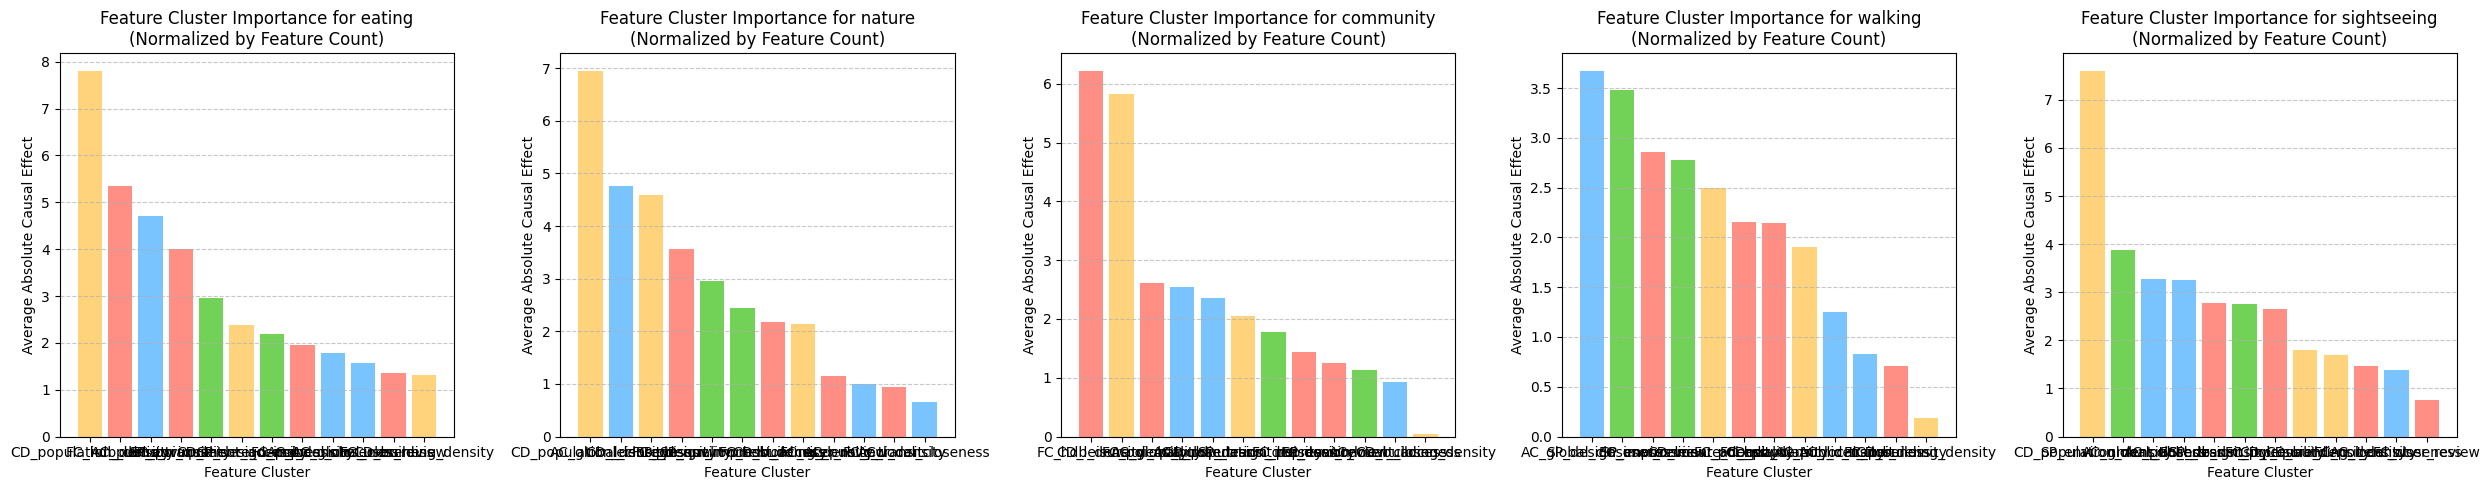


Feature Dimension Importance Rankings:

Target Variable: eating
Rank 1: CD - 3.8334
Rank 2: AC - 3.1893
Rank 3: FC - 2.9323
Rank 4: SP - 2.7175

Target Variable: nature
Rank 1: CD - 4.5502
Rank 2: SP - 2.6079
Rank 3: FC - 2.1245
Rank 4: AC - 1.8538

Target Variable: community
Rank 1: CD - 2.6405
Rank 2: FC - 2.1782
Rank 3: AC - 2.0499
Rank 4: SP - 1.3385

Target Variable: walking
Rank 1: SP - 2.9971
Rank 2: AC - 1.7505
Rank 3: FC - 1.6424
Rank 4: CD - 1.5317

Target Variable: sightseeing
Rank 1: CD - 3.6908
Rank 2: SP - 3.5305
Rank 3: AC - 2.7885
Rank 4: FC - 1.9423


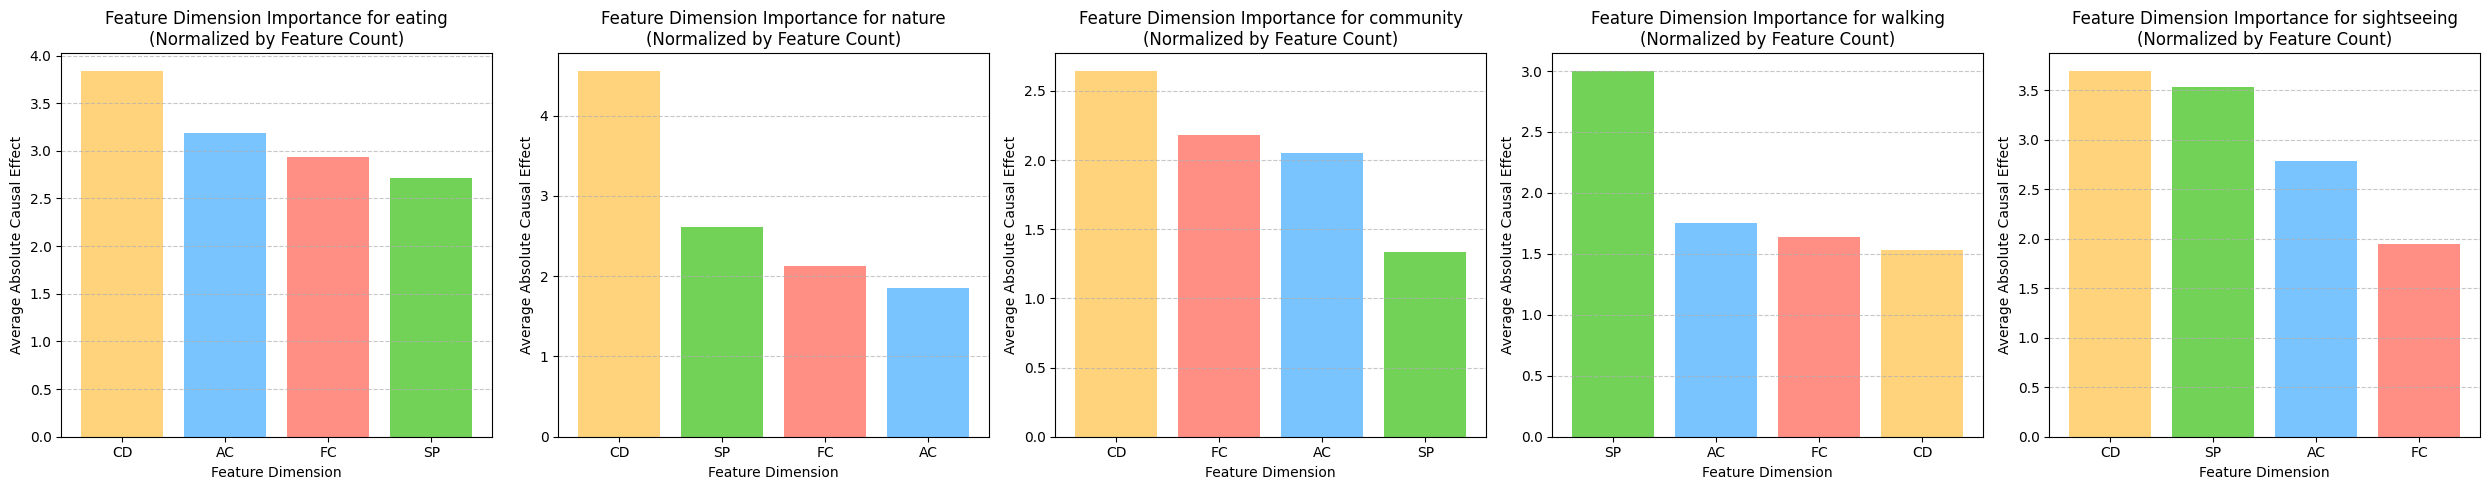

In [17]:
# -------------------------
# 5.2 Absolute-Effect Importance by Category/Dimension (No Pos/Neg Split)
# -------------------------
# Display the feature importance matrix
feature_importance

# Import seaborn for visualization
import seaborn as sns

# Match this notebook's variables
if "existing_acts" not in globals():
    raise RuntimeError("existing_acts is missing. Please run causal analytics blocks first.")
if "FEATURE_CATEGORY_RAW" not in globals():
    raise RuntimeError("FEATURE_CATEGORY_RAW is missing. Please run category mapping blocks first.")
if "DIMENSION_FEATURES" not in globals():
    raise RuntimeError("DIMENSION_FEATURES is missing. Please run dimension setup blocks first.")

target_columns = existing_acts
feature_clusters = FEATURE_CATEGORY_RAW
feature_dimensions = DIMENSION_FEATURES

# Calculate total weights of each feature_cluster for each target
cluster_importance = {}
for target in target_columns:
    cluster_importance[target] = {}
    for cluster_name, features in feature_clusters.items():
        # Only calculate for features that exist in feature_importance
        valid_features = [f for f in features if f in feature_importance.index]
        if valid_features:
            # Calculate total weight of this cluster for current target
            total_weight = feature_importance.loc[valid_features, target].astype(float).abs().sum()
            # Normalize by the number of features in the cluster
            normalized_weight = total_weight / len(valid_features)
            cluster_importance[target][cluster_name] = normalized_weight

# Calculate total weights of each feature_dimension for each target
dimension_importance_abs = {}
for target in target_columns:
    dimension_importance_abs[target] = {}
    for dim_name, features in feature_dimensions.items():
        # Only calculate for features that exist in feature_importance
        valid_features = [f for f in features if f in feature_importance.index]
        if valid_features:
            # Calculate total weight of this dimension for current target
            total_weight = feature_importance.loc[valid_features, target].astype(float).abs().sum()
            # Normalize by the number of features in the dimension
            normalized_weight = total_weight / len(valid_features)
            dimension_importance_abs[target][dim_name] = normalized_weight

# Define consistent colors for each dimension prefix
dimension_colors = {
    "SP": "#72D257",  # green
    "FC": "#FF8E84",  # coral
    "AC": "#79C4FF",  # blue
    "CD": "#FFD37B",  # yellow
}

# Print ranking and values for feature clusters
print("Feature Cluster Importance Rankings:")
for target in target_columns:
    print(f"\n{'='*50}")
    print(f"Target Variable: {target}")

    # Convert dictionary to DataFrame for ranking
    cluster_df = pd.DataFrame(list(cluster_importance[target].items()),
                             columns=['Cluster', 'Importance'])
    cluster_df = cluster_df.sort_values('Importance', ascending=False)

    # Print ranking with values
    for rank, (idx, row) in enumerate(cluster_df.iterrows(), 1):
        print(f"Rank {rank}: {row['Cluster']} - {row['Importance']:.4f}")

# Visualize weights of feature_clusters
plt.figure(figsize=(25, 5))
for i, target in enumerate(target_columns):
    plt.subplot(1, max(1, len(target_columns)), i + 1)

    # Convert dictionary to DataFrame for plotting
    cluster_df = pd.DataFrame(list(cluster_importance[target].items()),
                             columns=['Cluster', 'Importance'])
    cluster_df = cluster_df.sort_values('Importance', ascending=False)

    # Assign colors based on cluster prefix
    colors = []
    for cluster in cluster_df['Cluster']:
        prefix = cluster.split('_')[0]
        colors.append(dimension_colors.get(prefix, '#9467bd'))

    bars = plt.bar(cluster_df['Cluster'], cluster_df['Importance'], color=colors)
    plt.title(f'Feature Cluster Importance for {target}\n(Normalized by Feature Count)', fontsize=12)
    plt.ylabel('Average Absolute Causal Effect', fontsize=10)
    plt.xlabel('Feature Cluster', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

plt.show()

# Print ranking and values for feature dimensions
print("\nFeature Dimension Importance Rankings:")
for target in target_columns:
    print(f"\n{'='*50}")
    print(f"Target Variable: {target}")

    # Convert dictionary to DataFrame for ranking
    dim_df = pd.DataFrame(list(dimension_importance_abs[target].items()),
                         columns=['Dimension', 'Importance'])
    dim_df = dim_df.sort_values('Importance', ascending=False)

    # Print ranking with values
    for rank, (idx, row) in enumerate(dim_df.iterrows(), 1):
        print(f"Rank {rank}: {row['Dimension']} - {row['Importance']:.4f}")

# Visualize weights of feature_dimensions
plt.figure(figsize=(25, 5))
for i, target in enumerate(target_columns):
    plt.subplot(1, max(1, len(target_columns)), i + 1)

    # Convert dictionary to DataFrame for plotting
    dim_df = pd.DataFrame(list(dimension_importance_abs[target].items()),
                         columns=['Dimension', 'Importance'])
    dim_df = dim_df.sort_values('Importance', ascending=False)

    # Assign colors based on dimension prefix
    colors = []
    for dim in dim_df['Dimension']:
        prefix = dim.split('_')[0]
        colors.append(dimension_colors.get(prefix, '#9467bd'))

    bars = plt.bar(dim_df['Dimension'], dim_df['Importance'], color=colors)
    plt.title(f'Feature Dimension Importance for {target}\n(Normalized by Feature Count)', fontsize=12)
    plt.ylabel('Average Absolute Causal Effect', fontsize=10)
    plt.xlabel('Feature Dimension', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

plt.show()

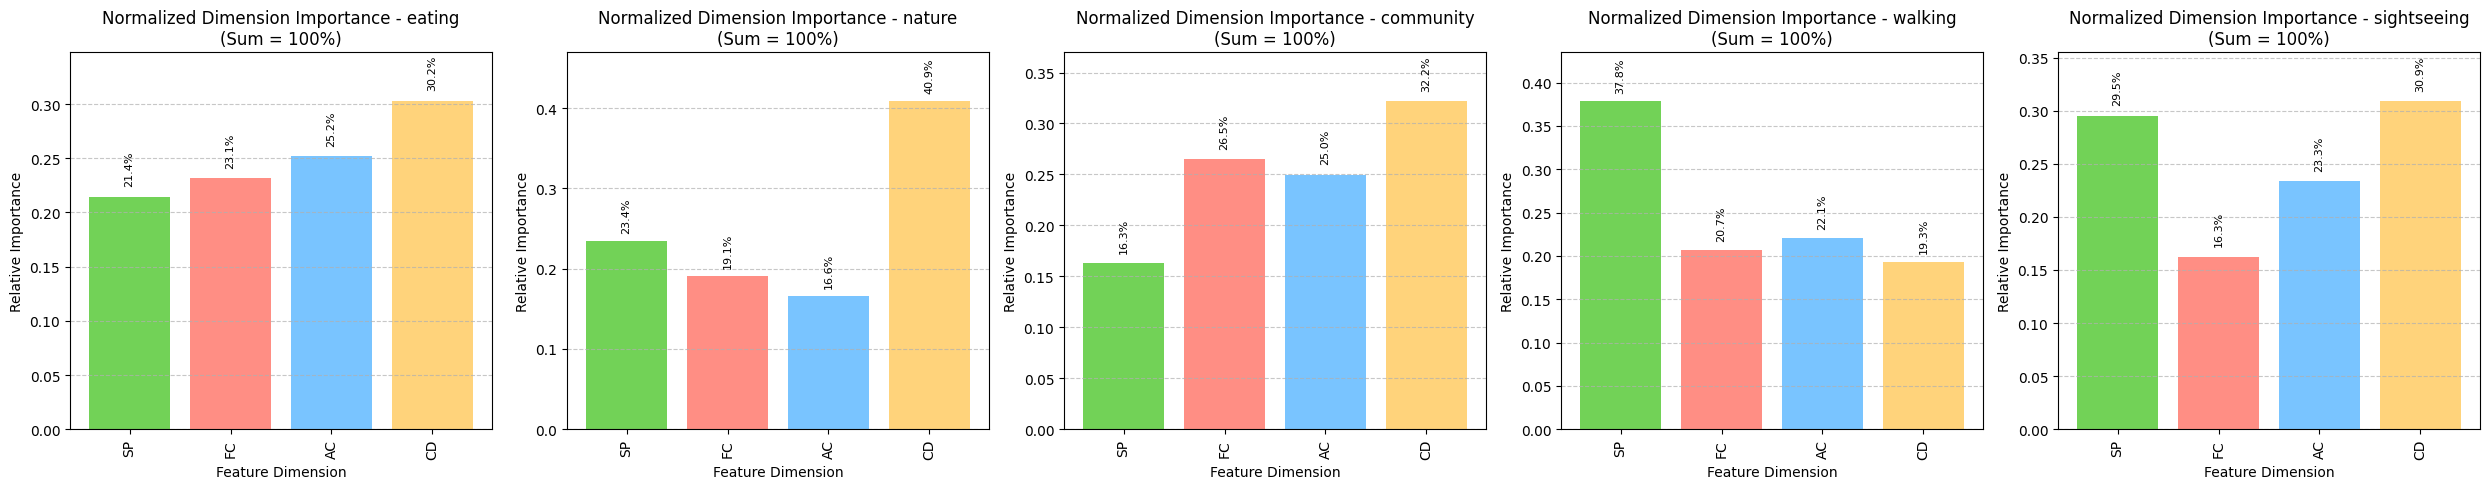

In [18]:
# -------------------------
# 5.3 Normalized Dimension Importance (from Absolute-Effect Module)
# -------------------------
# Reuse results from 2e; fallback to dimension_importance if needed
if "dimension_importance_abs" in globals():
    _dim_src = dimension_importance_abs
elif "dimension_importance" in globals():
    _dim_src = dimension_importance
else:
    raise RuntimeError("Please run 5.2 first (dimension_importance_abs missing).")

target_columns = list(_dim_src.keys())

# Keep target->dimension normalized table (dict of dict)
normalized_causal_importance_targetdim = {}
for target in target_columns:
    target_dims = _dim_src[target]
    total_importance = sum(target_dims.values())
    normalized_causal_importance_targetdim[target] = {
        dim: (value / total_importance) if total_importance > 0 else 0.0
        for dim, value in target_dims.items()
    }

# Visualize normalized dimension importance
plt.figure(figsize=(25, 5))
for i, target in enumerate(target_columns):
    plt.subplot(1, max(1, len(target_columns)), i + 1)

    norm_dim_df = pd.DataFrame(list(normalized_causal_importance_targetdim[target].items()),
                               columns=['Dimension', 'Importance'])

    # Reorder dimensions to follow SP, FC, AC, CD order
    dimension_order = []
    for prefix in ['SP', 'FC', 'AC', 'CD']:
        prefix_dims = [dim for dim in norm_dim_df['Dimension'] if str(dim).startswith(prefix)]
        prefix_dims.sort()
        dimension_order.extend(prefix_dims)

    norm_dim_df = norm_dim_df[norm_dim_df['Dimension'].isin(dimension_order)].copy()
    norm_dim_df['Order'] = norm_dim_df['Dimension'].apply(lambda x: dimension_order.index(x))
    norm_dim_df = norm_dim_df.sort_values('Order')

    colors = []
    for dim in norm_dim_df['Dimension']:
        prefix = str(dim).split('_')[0]
        colors.append(dimension_colors.get(prefix, '#9467bd'))

    bars = plt.bar(norm_dim_df['Dimension'], norm_dim_df['Importance'], color=colors)

    for bar, value in zip(bars, norm_dim_df['Importance']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{value:.1%}', ha='center', va='bottom', fontsize=8, rotation=90)

    plt.title(f'Normalized Dimension Importance - {target}\n(Sum = 100%)', fontsize=12)
    plt.ylabel('Relative Importance', fontsize=10)
    plt.xlabel('Feature Dimension', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, max(norm_dim_df['Importance']) * 1.15 if len(norm_dim_df) > 0 else 1)
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


# Build normalized_causal_importance for downstream use.
# key: ACT_COLUMNS activity names, value: [SP, FC, AC, CD] shares
if "ACT_COLUMNS" in globals() and len(ACT_COLUMNS) > 0:
    activity_list = [a for a in ACT_COLUMNS if a in normalized_causal_importance_targetdim]
else:
    activity_list = list(normalized_causal_importance_targetdim.keys())

dim_order = ["SP", "FC", "AC", "CD"]
normalized_causal_importance = {}
for act in activity_list:
    vals = [normalized_causal_importance_targetdim.get(act, {}).get(d, 0.0) for d in dim_order]
    total = sum(vals)
    normalized_causal_importance[act] = [(v / total) if total > 0 else 0.0 for v in vals]


## 6. Export Normalized Causal Importance

Run the following cell to persist `normalized_causal_importance` for downstream workflows.


In [19]:
# -------------------------
# 6.1 Export normalized_causal_importance
# -------------------------
import json
from pathlib import Path

if "normalized_causal_importance" not in globals():
    raise RuntimeError("normalized_causal_importance not found. Run the causal-importance cells first.")

export_path = Path("data/data_uci_dimension_causal_importance.json")
export_path.parent.mkdir(parents=True, exist_ok=True)

with export_path.open("w", encoding="utf-8") as f:
    json.dump(normalized_causal_importance, f, ensure_ascii=False, indent=2)

print(f"Exported: {export_path}")
print(f"Activities: {list(normalized_causal_importance.keys())}")

Exported: data/data_uci_dimension_causal_importance.json
Activities: ['eating', 'nature', 'community', 'walking', 'sightseeing']
